In [1]:
!pip install yfinance pyarrow arch pytorch-forecasting pytorch-lightning mlflow optuna -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from pathlib import Path
from arch import arch_model
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from google.colab import drive

In [3]:
drive.mount('/content/drive')
PROJECT_DIR = "/content/drive/MyDrive/vol_forecasting"
Path(PROJECT_DIR).mkdir(parents=True, exist_ok=True)
print("Project directory ready:", PROJECT_DIR)

Mounted at /content/drive
Project directory ready: /content/drive/MyDrive/vol_forecasting


In [4]:
TICKERS = [
    "AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "BRK-B",
    "LLY", "AVGO", "JPM", "TSLA", "UNH", "V", "XOM", "MA",
    "JNJ", "PG", "HD", "MRK", "COST", "ABBV", "CVX", "CRM",
    "BAC", "NFLX", "AMD", "PEP", "KO", "TMO", "ADBE", "WMT",
    "MCD", "CSCO", "ACN", "ABT", "LIN", "DHR", "TXN", "QCOM",
    "NKE", "PM", "INTU", "CAT", "MS", "GS", "AMGN", "SPGI",
    "BLK", "RTX", "T"
]

print(f"Downloading {len(TICKERS)} tickers...")
raw = yf.download(TICKERS, start="2018-01-01", end="2024-12-31",
                  auto_adjust=True, progress=True)

print(f"\nDownloading VIX...")
vix_raw = yf.download("^VIX", start="2018-01-01", end="2024-12-31",
                      auto_adjust=True, progress=False)

print(f"\nRaw shape: {raw.shape}")
print("Done.")

[*********************100%***********************]  50 of 50 completed




Raw shape: (1760, 250)
Done.


In [5]:
frames = []
for ticker in TICKERS:
    try:
        df_t = raw.xs(ticker, axis=1, level=1).copy()
        df_t["ticker"] = ticker
        df_t.index.name = "date"
        frames.append(df_t)
    except KeyError:
        print(f"Skipping {ticker} — no data")

df = pd.concat(frames).reset_index()
df.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in df.columns]
df = df.dropna(subset=["close"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"])

print(f"Shape: {df.shape}")
print(f"Tickers: {df['ticker'].nunique()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(df.head())

Shape: (88000, 7)
Tickers: 50
Date range: 2018-01-02 → 2024-12-30
        date      close       high        low       open     volume ticker
0 2018-01-02  40.267071  40.276423  39.565798  39.776182  102223600   AAPL
1 2018-01-03  40.260056  40.802375  40.196944  40.330184  118071600   AAPL
2 2018-01-04  40.447067  40.549921  40.224998  40.332525   89738400   AAPL
3 2018-01-05  40.907574  40.994063  40.451747  40.542912   94640000   AAPL
4 2018-01-08  40.755619  41.050152  40.657438  40.755619   82271200   AAPL


In [12]:
df.tail()

,date,close,high,low,open,volume,ticker
87995,2024-12-23,101.171158,101.456679,99.857737,100.228919,12285100,XOM
87996,2024-12-24,101.266319,102.018204,100.600089,101.380525,7807000,XOM
87997,2024-12-26,101.351974,101.865921,100.828516,101.380526,9652400,XOM
87998,2024-12-27,101.342468,102.779607,100.666719,101.171153,11943900,XOM
87999,2024-12-30,100.657204,101.418600,100.419266,101.171150,11080800,XOM


In [13]:
import urllib.request

def get_sp500_meta():
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "Mozilla/5.0"}
    req = urllib.request.Request(url, headers=headers)
    response = urllib.request.urlopen(req)
    table = pd.read_html(response)[0]
    meta = table[["Symbol", "Security", "GICS Sector"]].copy()
    meta.columns = ["ticker", "company", "sector"]
    meta["ticker"] = meta["ticker"].str.replace(".", "-", regex=False)
    return meta

meta = get_sp500_meta()
df = df.merge(meta, on="ticker", how="left")

print("Missing company names:", df["company"].isna().sum())
print(df[["ticker", "company", "sector"]].drop_duplicates().head(10))

Missing company names: 0
      ticker                 company                  sector
0       AAPL              Apple Inc.  Information Technology
1760    ABBV                  AbbVie             Health Care
3520     ABT     Abbott Laboratories             Health Care
5280     ACN               Accenture  Information Technology
7040    ADBE              Adobe Inc.  Information Technology
8800     AMD  Advanced Micro Devices  Information Technology
10560   AMGN                   Amgen             Health Care
12320   AMZN                  Amazon  Consumer Discretionary
14080   AVGO                Broadcom  Information Technology
15840    BAC         Bank of America              Financials


In [14]:
HORIZON = 5  # predicting 5 trading days ahead

# ── VIX — clean and align ─────────────────────────────────────────────────────
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)
vix = vix_raw[["Close"]].rename(columns={"Close": "vix"}).reset_index()
vix.columns = [c.lower() for c in vix.columns]
vix["date"] = pd.to_datetime(vix["date"])

# ── Log returns ───────────────────────────────────────────────────────────────
df["log_ret"] = df.groupby("ticker")["close"].transform(
    lambda x: np.log(x / x.shift(1))
)

# ── Realized volatility (20-day rolling, annualized) ─────────────────────────
df["real_vol"] = df.groupby("ticker")["log_ret"].transform(
    lambda x: x.rolling(20).std() * np.sqrt(252)
)

# ── TARGET: future realized vol — what the model will predict ─────────────────
df["target"] = df.groupby("ticker")["real_vol"].transform(
    lambda x: x.shift(-HORIZON)
)

# ── Lag features ──────────────────────────────────────────────────────────────
for lag in [1, 5, 20]:
    df[f"vol_lag{lag}"] = df.groupby("ticker")["real_vol"].transform(
        lambda x, l=lag: x.shift(l)
    )

# ── EWMA volatility ───────────────────────────────────────────────────────────
df["ewma_vol"] = df.groupby("ticker")["log_ret"].transform(
    lambda x: x.pow(2).ewm(span=20, adjust=False).mean().apply(np.sqrt) * np.sqrt(252)
)

# ── Cyclic time encodings ─────────────────────────────────────────────────────
df["day_sin"]   = np.sin(2 * np.pi * df["date"].dt.dayofweek / 5)
df["day_cos"]   = np.cos(2 * np.pi * df["date"].dt.dayofweek / 5)
df["month_sin"] = np.sin(2 * np.pi * df["date"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["date"].dt.month / 12)

# ── Volume ratio (today vs 20-day average) ────────────────────────────────────
df["volume_ratio"] = df.groupby("ticker")["volume"].transform(
    lambda x: x / x.rolling(20).mean()
)

# ── Merge VIX ─────────────────────────────────────────────────────────────────
df = df.merge(vix, on="date", how="left")
df["vix"] = df["vix"].ffill()

# ── Cap bucket (static covariate) ─────────────────────────────────────────────
avg_price = df.groupby("ticker")["close"].mean()
bucket_map = pd.cut(avg_price, bins=3, labels=["small", "mid", "large"]).to_dict()
df["cap_bucket"] = df["ticker"].map(bucket_map)

# ── time_idx (required by pytorch-forecasting) ────────────────────────────────
df["time_idx"] = df.groupby("ticker").cumcount()

print("Features computed. Columns:", df.columns.tolist())
print("Shape:", df.shape)

Features computed. Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'company', 'sector', 'log_ret', 'real_vol', 'target', 'vol_lag1', 'vol_lag5', 'vol_lag20', 'ewma_vol', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'volume_ratio', 'vix', 'cap_bucket', 'time_idx']
Shape: (88000, 24)


Preprocessing

In [15]:
df_clean = df.dropna(subset=[
    "target", "vol_lag1", "vol_lag5", "vol_lag20", "vix", "ewma_vol"
]).copy().reset_index(drop=True)

print(f"Rows before clean: {len(df):,}")
print(f"Rows after clean:  {len(df_clean):,}")
print(f"Tickers retained:  {df_clean['ticker'].nunique()}")

df_clean.to_parquet(f"{PROJECT_DIR}/features.parquet", index=False, compression="snappy")
print(f"\nSaved → {PROJECT_DIR}/features.parquet")

Rows before clean: 88,000
Rows after clean:  85,750
Tickers retained:  50

Saved → /content/drive/MyDrive/vol_forecasting/features.parquet


Baseline predictions (running,historical...)

In [17]:
# ── Metric helper functions ───────────────────────────────────────────────────
def rmse(actual, pred):
    return round(np.sqrt(mean_squared_error(actual, pred)), 4)

def mae(actual, pred):
    return round(mean_absolute_error(actual, pred), 4)

In [18]:
SPLIT_DATE = "2022-01-01"

all_results = []

for ticker in df_clean["ticker"].unique():
    tkr = df_clean[df_clean["ticker"] == ticker].sort_values("date").reset_index(drop=True)

    test = tkr[tkr["date"] >= SPLIT_DATE].copy()

    # Need enough test rows
    if len(test) < 50:
        continue

    # Random walk
    test["rw_pred"] = test["real_vol"].shift(1)

    # Historical average — 60-day rolling mean on full series, sliced to test
    rolling_mean = tkr.set_index("date")["real_vol"].rolling(60).mean()
    test["hist_avg_pred"] = rolling_mean.reindex(test["date"].values).values

    # EWMA — already computed in features
    test["ewma_pred"] = test["ewma_vol"]

    test = test.dropna(subset=["rw_pred", "hist_avg_pred", "ewma_pred", "real_vol"])

    if len(test) < 10:
        continue

    actual = test["real_vol"]

    all_results.append({
        "ticker":       ticker,
        "rw_rmse":      rmse(actual, test["rw_pred"]),
        "rw_mae":       mae(actual,  test["rw_pred"]),
        "hist_rmse":    rmse(actual, test["hist_avg_pred"]),
        "hist_mae":     mae(actual,  test["hist_avg_pred"]),
        "ewma_rmse":    rmse(actual, test["ewma_pred"]),
        "ewma_mae":     mae(actual,  test["ewma_pred"]),
    })

baseline_results = pd.DataFrame(all_results)
print(f"Tickers evaluated: {len(baseline_results)}")
print(baseline_results.head(10).to_string(index=False))

Tickers evaluated: 50
ticker  rw_rmse  rw_mae  hist_rmse  hist_mae  ewma_rmse  ewma_mae
  AAPL   0.0178  0.0095     0.0678    0.0552     0.0278    0.0217
  ABBV   0.0231  0.0088     0.0783    0.0517     0.0336    0.0238
   ABT   0.0164  0.0083     0.0564    0.0467     0.0264    0.0197
   ACN   0.0210  0.0103     0.0714    0.0585     0.0297    0.0227
  ADBE   0.0390  0.0153     0.1160    0.0876     0.0577    0.0419
   AMD   0.0352  0.0190     0.1061    0.0892     0.0541    0.0434
  AMGN   0.0217  0.0088     0.0717    0.0553     0.0351    0.0252
  AMZN   0.0288  0.0138     0.1046    0.0802     0.0494    0.0368
  AVGO   0.0314  0.0149     0.1110    0.0792     0.0506    0.0354
   BAC   0.0190  0.0103     0.0674    0.0518     0.0333    0.0256


Computing GARCH

In [19]:
garch_results = []

for i, ticker in enumerate(df_clean["ticker"].unique()):
    print(f"[{i+1}/{df_clean['ticker'].nunique()}] {ticker}", end=" ... ")

    tkr = df_clean[df_clean["ticker"] == ticker].sort_values("date").reset_index(drop=True)
    test = tkr[tkr["date"] >= SPLIT_DATE].copy()

    if len(test) < 50:
        print("skipped (too few rows)")
        continue

    returns_all = tkr["log_ret"] * 100
    test_indices = test.index.tolist()

    garch_preds = []
    fitted_res  = None

    for count, idx in enumerate(test_indices):
        history = returns_all.iloc[:tkr.index.get_loc(idx)]
        if len(history) < 100:
            garch_preds.append(np.nan)
            continue
        # Refit every 20 days
        if count % 20 == 0 or fitted_res is None:
            try:
                m = arch_model(history, vol="Garch", p=1, q=1, dist="normal")
                fitted_res = m.fit(disp="off", show_warning=False)
            except:
                garch_preds.append(np.nan)
                continue
        try:
            fc  = fitted_res.forecast(horizon=1, reindex=False)
            vol = np.sqrt(fc.variance.values[-1, 0]) * np.sqrt(252) / 100
            garch_preds.append(vol)
        except:
            garch_preds.append(np.nan)

    test = test.copy()
    test["garch_pred"] = garch_preds
    test = test.dropna(subset=["garch_pred", "real_vol"])

    if len(test) < 10:
        print("skipped (too few valid preds)")
        continue

    garch_results.append({
        "ticker":     ticker,
        "garch_rmse": rmse(test["real_vol"], test["garch_pred"]),
        "garch_mae":  mae(test["real_vol"],  test["garch_pred"]),
    })
    print(f"RMSE={garch_results[-1]['garch_rmse']}")

garch_df = pd.DataFrame(garch_results)
print(f"\nGARCH evaluated on {len(garch_df)} tickers")

[1/50] AAPL ... RMSE=0.0616
[2/50] ABBV ... RMSE=0.0779
[3/50] ABT ... RMSE=0.0518
[4/50] ACN ... RMSE=0.064
[5/50] ADBE ... RMSE=0.1267
[6/50] AMD ... RMSE=0.0879
[7/50] AMGN ... RMSE=0.0678
[8/50] AMZN ... RMSE=0.1014
[9/50] AVGO ... RMSE=0.0957
[10/50] BAC ... RMSE=0.0606
[11/50] BLK ... RMSE=0.0588
[12/50] BRK-B ... RMSE=0.0394
[13/50] CAT ... RMSE=0.0666
[14/50] COST ... RMSE=0.06
[15/50] CRM ... RMSE=0.1321
[16/50] CSCO ... RMSE=0.0754
[17/50] CVX ... RMSE=0.0603
[18/50] DHR ... RMSE=0.0659
[19/50] GOOGL ... RMSE=0.0769
[20/50] GS ... RMSE=0.0659
[21/50] HD ... RMSE=0.05
[22/50] INTU ... RMSE=0.0693
[23/50] JNJ ... RMSE=0.0373
[24/50] JPM ... RMSE=0.0642
[25/50] KO ... RMSE=0.0446
[26/50] LIN ... RMSE=0.0518
[27/50] LLY ... RMSE=0.0822
[28/50] MA ... RMSE=0.0673
[29/50] MCD ... RMSE=0.0423
[30/50] META ... RMSE=0.2101
[31/50] MRK ... RMSE=0.0498
[32/50] MS ... RMSE=0.0632
[33/50] MSFT ... RMSE=0.0499
[34/50] NFLX ... RMSE=0.1973
[35/50] NKE ... RMSE=0.1254
[36/50] NVDA ... RMSE=0

Merging

In [20]:
summary = baseline_results.merge(garch_df, on="ticker", how="inner")

# Mean across all tickers — this is your headline results table
mean_row = summary.drop(columns="ticker").mean().round(4)
print("=== MEAN ACROSS ALL TICKERS ===")
print(f"{'Model':<18} {'RMSE':>8} {'MAE':>8}")
print("-" * 36)
print(f"{'Random Walk':<18} {mean_row['rw_rmse']:>8} {mean_row['rw_mae']:>8}")
print(f"{'Hist Average':<18} {mean_row['hist_rmse']:>8} {mean_row['hist_mae']:>8}")
print(f"{'EWMA':<18} {mean_row['ewma_rmse']:>8} {mean_row['ewma_mae']:>8}")
print(f"{'GARCH(1,1)':<18} {mean_row['garch_rmse']:>8} {mean_row['garch_mae']:>8}")

# Save for later comparison with TFT
summary.to_parquet(f"{PROJECT_DIR}/baseline_results.parquet", index=False)
print(f"\nSaved baseline_results.parquet")

=== MEAN ACROSS ALL TICKERS ===
Model                  RMSE      MAE
------------------------------------
Random Walk           0.024   0.0107
Hist Average         0.0795   0.0602
EWMA                 0.0373   0.0269
GARCH(1,1)           0.0751   0.0558

Saved baseline_results.parquet


Plotting best and worst result

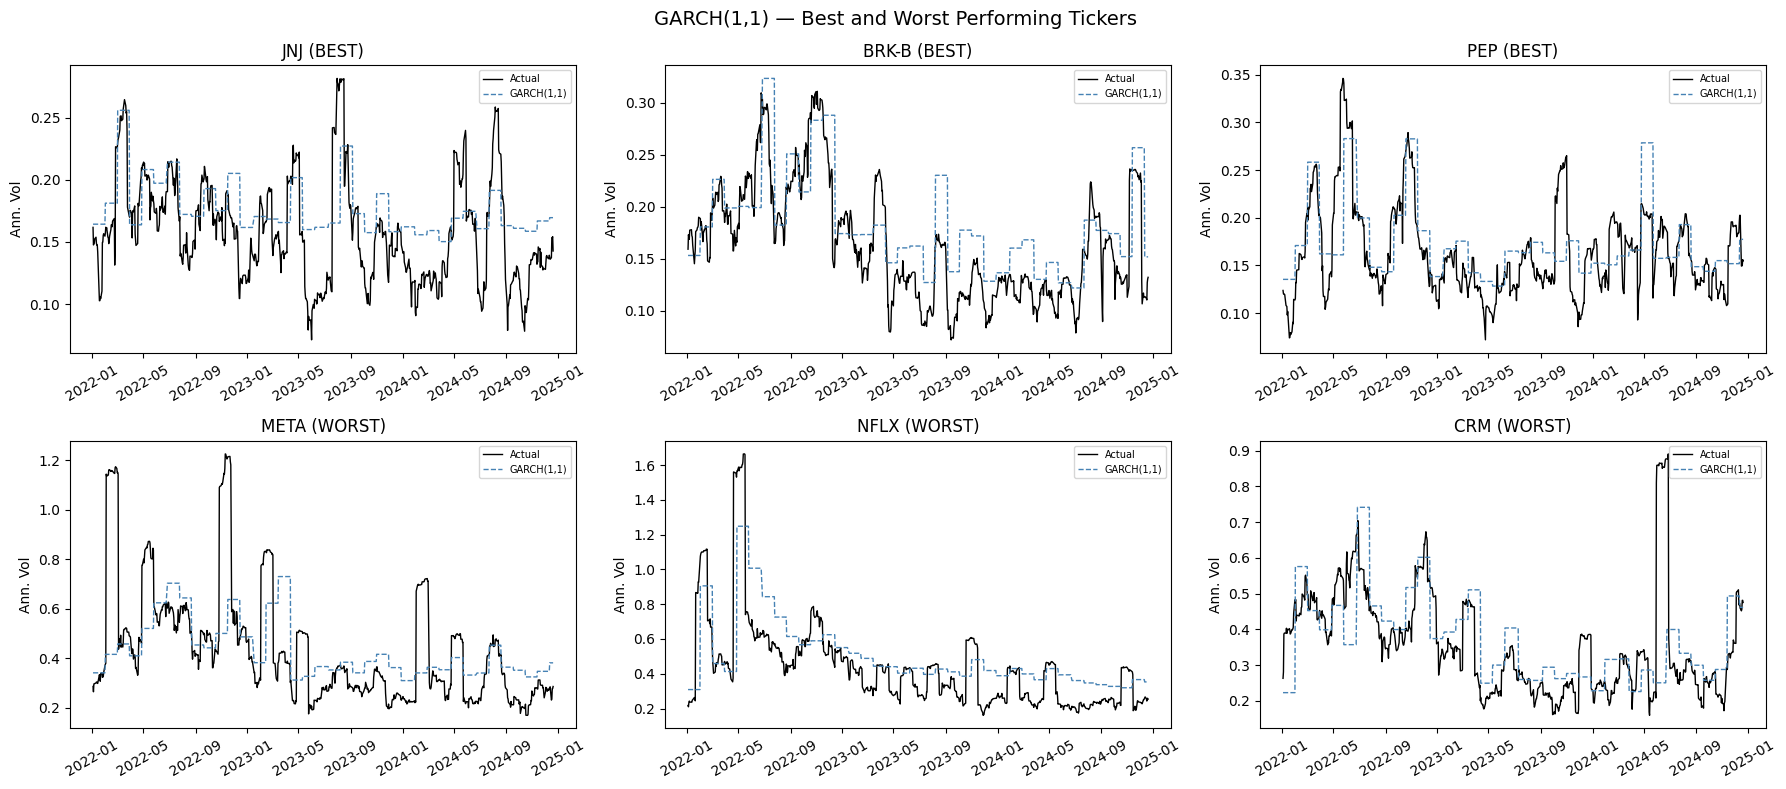

In [21]:
best3  = summary.nsmallest(3,  "garch_rmse")["ticker"].tolist()
worst3 = summary.nlargest(3,   "garch_rmse")["ticker"].tolist()
show   = best3 + worst3

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for ax, ticker in zip(axes, show):
    tkr  = df_clean[df_clean["ticker"] == ticker].sort_values("date").reset_index(drop=True)
    test = tkr[tkr["date"] >= SPLIT_DATE].copy()

    returns_all = tkr["log_ret"] * 100
    preds, fitted_res = [], None
    for count, idx in enumerate(test.index.tolist()):
        history = returns_all.iloc[:tkr.index.get_loc(idx)]
        if len(history) < 100:
            preds.append(np.nan); continue
        if count % 20 == 0 or fitted_res is None:
            try:
                m = arch_model(history, vol="Garch", p=1, q=1, dist="normal")
                fitted_res = m.fit(disp="off", show_warning=False)
            except:
                preds.append(np.nan); continue
        try:
            fc  = fitted_res.forecast(horizon=1, reindex=False)
            vol = np.sqrt(fc.variance.values[-1, 0]) * np.sqrt(252) / 100
            preds.append(vol)
        except:
            preds.append(np.nan)

    test = test.copy()
    test["garch_pred"] = preds
    test = test.dropna(subset=["garch_pred"])

    label = "BEST" if ticker in best3 else "WORST"
    ax.plot(test["date"], test["real_vol"],   label="Actual",     color="black",    lw=1)
    ax.plot(test["date"], test["garch_pred"], label="GARCH(1,1)", color="steelblue",lw=1, ls="--")
    ax.set_title(f"{ticker} ({label})")
    ax.set_ylabel("Ann. Vol")
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("GARCH(1,1) — Best and Worst Performing Tickers", fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
import os
files = ["features.parquet", "baseline_results.parquet"]
for f in files:
    path = f"{PROJECT_DIR}/{f}"
    if os.path.exists(path):
        size = os.path.getsize(path) / 1e6
        print(f"✅ {f}  ({size:.1f} MB)")
    else:
        print(f"❌ {f} — NOT FOUND")

✅ features.parquet  (11.1 MB)
✅ baseline_results.parquet  (0.0 MB)
